In [26]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import pandas as pd

data_dir = Path('../data/processed')

# Feature matrices
X_train = pd.read_parquet(data_dir / 'X_train.parquet')
X_test  = pd.read_parquet(data_dir / 'X_test.parquet')

# Labels (3-class: 0=Fail, 1=Pass, 2=Withdrawn)
y_train = pd.read_parquet(data_dir / 'y_train.parquet').squeeze()
y_test  = pd.read_parquet(data_dir / 'y_test.parquet').squeeze()

# Snapshot metadata (prediction_point per row)
train_meta = pd.read_parquet(data_dir / 'train_meta.parquet')
test_meta  = pd.read_parquet(data_dir / 'test_meta.parquet')

# Full processed datasets (features + label + meta)
train = pd.read_parquet(data_dir / 'train.parquet')
test  = pd.read_parquet(data_dir / 'test.parquet')

print('X_train:', X_train.shape)
print('X_test: ', X_test.shape)
print('y_train:', y_train.shape, '| classes:', y_train.value_counts().to_dict())
print('y_test: ', y_test.shape,  '| classes:', y_test.value_counts().to_dict())
print('train:  ', train.shape)
print('test:   ', test.shape)
print('train_meta:', train_meta.shape)
print('test_meta: ', test_meta.shape)

X_train: (142384, 15)
X_test:  (35910, 15)
y_train: (142384,) | classes: {1: 88536, 0: 40333, 2: 13515}
y_test:  (35910,) | classes: {1: 22432, 0: 10192, 2: 3286}
train:   (142384, 22)
test:    (35910, 22)
train_meta: (142384, 1)
test_meta:  (35910, 1)


In [27]:
SNAPSHOTS_3 = [90, 180, 240]

# Mask theo prediction_point
mask_tr = train_meta['prediction_point'].isin(SNAPSHOTS_3)
mask_te = test_meta['prediction_point'].isin(SNAPSHOTS_3)

X_train_3 = X_train[mask_tr].reset_index(drop=True)
X_test_3  = X_test[mask_te].reset_index(drop=True)
y_train_3 = y_train[mask_tr].reset_index(drop=True)
y_test_3  = y_test[mask_te].reset_index(drop=True)
train_meta_3 = train_meta[mask_tr].reset_index(drop=True)
test_meta_3  = test_meta[mask_te].reset_index(drop=True)
train_3 = train[mask_tr].reset_index(drop=True)
test_3  = test[mask_te].reset_index(drop=True)

print('Snapshots giữ lại:', SNAPSHOTS_3)
print()
print(f'X_train_3:    {X_train_3.shape}')
print(f'X_test_3:     {X_test_3.shape}')
print(f'y_train_3:    {y_train_3.shape} | classes: {y_train_3.value_counts().to_dict()}')
print(f'y_test_3:     {y_test_3.shape}  | classes: {y_test_3.value_counts().to_dict()}')
print(f'train_3:      {train_3.shape}')
print(f'test_3:       {test_3.shape}')
print()
print('Phân phối rows theo prediction_point (train):')
print(train_meta_3['prediction_point'].value_counts().sort_index())

Snapshots giữ lại: [90, 180, 240]

X_train_3:    (51484, 15)
X_test_3:     (12989, 15)
y_train_3:    (51484,) | classes: {1: 33201, 0: 15124, 2: 3159}
y_test_3:     (12989,)  | classes: {1: 8412, 0: 3822, 2: 755}
train_3:      (51484, 22)
test_3:       (12989, 22)

Phân phối rows theo prediction_point (train):
prediction_point
90     18508
180    16786
240    16190
Name: count, dtype: int64


In [28]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, accuracy_score, fbeta_score, f1_score,
    roc_curve, roc_auc_score,
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

from config import RANDOM_SEED

TARGET_NAMES   = ['Fail', 'Pass', 'Withdrawn']
TARGET_NAMES_2 = ['Pass', 'At-risk']
CLASSES        = [0, 1, 2]

### Helper functions

In [29]:
def get_snapshot_data(T):
    mask_tr = train_meta_3['prediction_point'].values == T
    mask_te = test_meta_3['prediction_point'].values == T
    return (
        X_train_3[mask_tr].reset_index(drop=True),
        X_test_3[mask_te].reset_index(drop=True),
        y_train_3[mask_tr].reset_index(drop=True),
        y_test_3[mask_te].reset_index(drop=True),
    )


def safe_smote(X, y, ratio_fail=0.5, ratio_withdrawn=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio ∈ [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_fail = (y_s == 0).sum()
    n_with = (y_s == 2).sum()
    target = {
        0: int((1 + ratio_fail) * n_fail),
        2: int((1 + ratio_withdrawn) * n_with),
    }
    k = max(1, min(5, n_with - 1, n_fail - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

---

## Vòng lặp — 3 prediction_point (90 / 180 / 240)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (max_iter, learning_rate, max_depth, ...)
- SMOTE ratio cho Fail và Withdrawn (`smote_ratio_fail`, `smote_ratio_withdrawn` ∈ [0.1, 0.9])
- Class weight cho Fail (`w_fail` ∈ [1, 5]) và Withdrawn (`w_withdrawn` ∈ [1, 8])

**Metric tối ưu:** F2-macro trên 2 lớp at-risk (Fail + Withdrawn, β=2)


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4617
SMOTE  → Fail: +0.89x | Withdrawn: +0.87x
Weight → Fail: 4.23 | Withdrawn: 7.97

  T=90
              precision    recall  f1-score   support

        Fail      0.412     0.681     0.514      1274
        Pass      0.905     0.412     0.566      2804
   Withdrawn      0.190     0.412     0.260       602

    accuracy                          0.485      4680
   macro avg      0.503     0.501     0.447      4680
weighted avg      0.679     0.485     0.512      4680



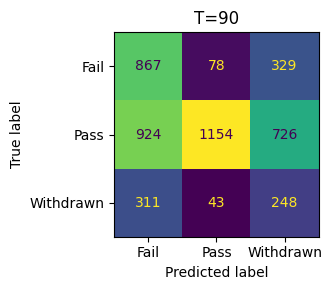


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.4487
SMOTE  → Fail: +0.56x | Withdrawn: +0.70x
Weight → Fail: 1.77 | Withdrawn: 6.61

  T=180
              precision    recall  f1-score   support

        Fail      0.721     0.750     0.735      1274
        Pass      0.899     0.888     0.893      2804
   Withdrawn      0.116     0.102     0.109       137

    accuracy                          0.820      4215
   macro avg      0.579     0.580     0.579      4215
weighted avg      0.820     0.820     0.820      4215



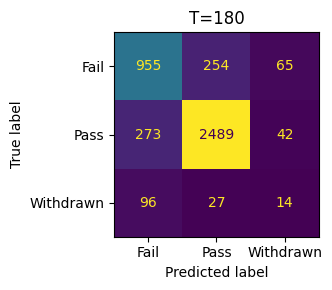


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F2 CV: 0.5177
SMOTE  → Fail: +0.60x | Withdrawn: +0.85x
Weight → Fail: 1.04 | Withdrawn: 4.83

  T=240
              precision    recall  f1-score   support

        Fail      0.858     0.766     0.810      1274
        Pass      0.905     0.946     0.925      2804
   Withdrawn      0.222     0.375     0.279        16

    accuracy                          0.888      4094
   macro avg      0.662     0.696     0.671      4094
weighted avg      0.888     0.888     0.887      4094



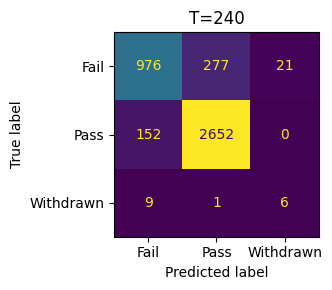


--- Tổng hợp ---


,prediction_point,accuracy,recall_fail,recall_pass,recall_withdrawn,macro_recall,precision_fail,precision_withdrawn,f2_at_risk
0,90,0.4848,0.6805,0.4116,0.4120,0.5013,0.4125,0.1903,0.4682
1,180,0.8204,0.7496,0.8877,0.1022,0.5798,0.7213,0.1157,0.4242
2,240,0.8876,0.7661,0.9458,0.3750,0.6956,0.8584,0.2222,0.5563


In [30]:
models  = {}
results = []

for T in SNAPSHOTS_3:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective(trial):
        params = {
            'max_iter':          trial.suggest_int('max_iter', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
            'random_state':      RANDOM_SEED,
        }
        r_fail = trial.suggest_float('smote_ratio_fail', 0.1, 0.9)
        r_with = trial.suggest_float('smote_ratio_withdrawn', 0.1, 0.9)
        w_fail = trial.suggest_float('w_fail', 1.0, 5.0)
        w_with = trial.suggest_float('w_withdrawn', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            Xf_sm, yf_sm = safe_smote(Xf_tr, yf_tr, r_fail, r_with)
            m = HistGradientBoostingClassifier(
                **params,
                class_weight={0: w_fail, 1: 1.0, 2: w_with},
            )
            m.fit(Xf_sm, yf_sm)

            score = fbeta_score(
                yf_val, m.predict(Xf_val),
                beta=2, average='macro', labels=[0, 2], zero_division=0,
            )
            fold_scores.append(score)
        return np.mean(fold_scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    best = study.best_params
    print(f'Best F2 CV: {study.best_value:.4f}')
    print(f'SMOTE  → Fail: +{best["smote_ratio_fail"]:.2f}x | Withdrawn: +{best["smote_ratio_withdrawn"]:.2f}x')
    print(f'Weight → Fail: {best["w_fail"]:.2f} | Withdrawn: {best["w_withdrawn"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    X_sm, y_sm = safe_smote(
        X_tr, y_tr,
        ratio_fail=best['smote_ratio_fail'],
        ratio_withdrawn=best['smote_ratio_withdrawn'],
    )
    model_final = HistGradientBoostingClassifier(
        max_iter=best['max_iter'],
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        l2_regularization=best['l2_regularization'],
        max_leaf_nodes=best['max_leaf_nodes'],
        class_weight={0: best['w_fail'], 1: 1.0, 2: best['w_withdrawn']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te))
    evaluate_full(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1, 2], zero_division=0)
    results.append({
        'prediction_point':    T,
        'accuracy':            round(accuracy_score(y_te, y_pred), 4),
        'recall_fail':         round(recalls[0], 4),
        'recall_pass':         round(recalls[1], 4),
        'recall_withdrawn':    round(recalls[2], 4),
        'macro_recall':        round(recalls.mean(), 4),
        'precision_fail':      round(precisions[0], 4),
        'precision_withdrawn': round(precisions[2], 4),
        'f2_at_risk':          round(fbeta_score(y_te, y_pred, beta=2, average='macro',
                                                  labels=[0, 2], zero_division=0), 4),
    })

results_df = pd.DataFrame(results)
print('\n--- Tổng hợp ---')
results_df

---

## Gộp At-risk (Fail + Withdrawn) — Binary Classification

Gộp **Fail (0)** và **Withdrawn (2)** thành **At-risk (1)**; **Pass (1) → 0**.

Cấu trúc giống phần 3-label ở trên: HistGB + SMOTE + Bayesian Optimization.  
**Metric tối ưu:** F1-score At-risk (thay vì F2 để tránh model thiên lệch hoàn toàn về At-risk).

In [31]:
# Gộp Fail (0) và Withdrawn (2) → At-risk (1); Pass (1) → 0
LABEL_MAP = {0: 1, 1: 0, 2: 1}
y_train_bin_3 = y_train_3.map(LABEL_MAP)
y_test_bin_3  = y_test_3.map(LABEL_MAP)

print('Phân phối nhãn binary (train):')
print(y_train_bin_3.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())
print('Phân phối nhãn binary (test):')
print(y_test_bin_3.value_counts().rename({0: 'Pass', 1: 'At-risk'}).to_dict())

Phân phối nhãn binary (train):
{'Pass': 33201, 'At-risk': 18283}
Phân phối nhãn binary (test):
{'Pass': 8412, 'At-risk': 4577}


### Helper functions (binary)

In [32]:
def get_snapshot_data_bin(T):
    mask_tr = train_meta_3['prediction_point'].values == T
    mask_te = test_meta_3['prediction_point'].values == T
    return (
        X_train_3[mask_tr].reset_index(drop=True),
        X_test_3[mask_te].reset_index(drop=True),
        y_train_bin_3[mask_tr].reset_index(drop=True),
        y_test_bin_3[mask_te].reset_index(drop=True),
    )


def safe_smote_bin(X, y, ratio_at_risk=0.5):
    """new_count = int((1 + ratio) * N_current),  ratio ∈ [0.1, 0.9]"""
    y_s = pd.Series(y)
    n_at_risk = (y_s == 1).sum()
    n_pass    = (y_s == 0).sum()
    target = {1: int((1 + ratio_at_risk) * n_at_risk)}
    k = max(1, min(5, n_at_risk - 1, n_pass - 1))
    smote = SMOTE(sampling_strategy=target, random_state=RANDOM_SEED, k_neighbors=k)
    cols = X.columns.tolist() if hasattr(X, 'columns') else None
    X_res, y_res = smote.fit_resample(np.array(X), np.array(y))
    return pd.DataFrame(X_res, columns=cols), pd.Series(y_res)


def evaluate_full_bin(name, y_true, y_pred):
    sep = '=' * 55
    print(f'\n{sep}\n  {name}\n{sep}')
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES_2, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES_2).plot(ax=ax, colorbar=False)
    ax.set_title(name)
    plt.tight_layout()
    plt.show()

### Vòng lặp binary — 3 prediction_point (90 / 180 / 240)

**Optuna tìm đồng thời:**
- Hyperparameter mô hình (max_iter, learning_rate, max_depth, ...)
- SMOTE ratio cho At-risk (`smote_ratio_at_risk` ∈ [0.1, 0.9])
- Class weight cho At-risk (`w_at_risk` ∈ [1, 8])


############################################################
  PREDICTION POINT = 90 days
############################################################
Train: 18,508 | Test: 4,680


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.7278
SMOTE  -> At-risk: +0.10x
Weight -> At-risk: 1.50

  T=90
              precision    recall  f1-score   support

        Pass      0.815     0.802     0.809      2804
     At-risk      0.711     0.728     0.719      1876

    accuracy                          0.772      4680
   macro avg      0.763     0.765     0.764      4680
weighted avg      0.773     0.772     0.773      4680



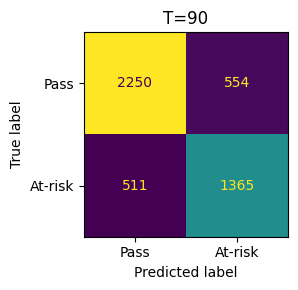


############################################################
  PREDICTION POINT = 180 days
############################################################
Train: 16,786 | Test: 4,215


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8062
SMOTE  -> At-risk: +0.30x
Weight -> At-risk: 1.67

  T=180
              precision    recall  f1-score   support

        Pass      0.903     0.886     0.894      2804
     At-risk      0.781     0.810     0.795      1411

    accuracy                          0.860      4215
   macro avg      0.842     0.848     0.845      4215
weighted avg      0.862     0.860     0.861      4215



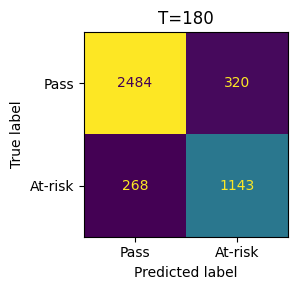


############################################################
  PREDICTION POINT = 240 days
############################################################
Train: 16,190 | Test: 4,094


  0%|          | 0/30 [00:00<?, ?it/s]

Best F1 At-risk CV: 0.8331
SMOTE  -> At-risk: +0.53x
Weight -> At-risk: 1.01

  T=240
              precision    recall  f1-score   support

        Pass      0.905     0.953     0.929      2804
     At-risk      0.885     0.784     0.831      1290

    accuracy                          0.900      4094
   macro avg      0.895     0.869     0.880      4094
weighted avg      0.899     0.900     0.898      4094



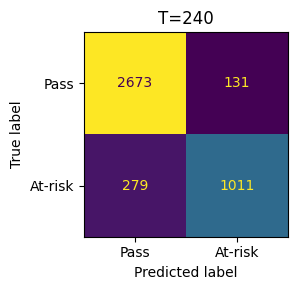


--- Tổng hợp binary ---


,prediction_point,accuracy,recall_pass,recall_at_risk,precision_pass,precision_at_risk,f1_at_risk
0,90,0.7724,0.8024,0.7276,0.8149,0.7113,0.7194
1,180,0.8605,0.8859,0.8101,0.9026,0.7813,0.7954
2,240,0.8999,0.9533,0.7837,0.9055,0.8853,0.8314


In [33]:
models_bin  = {}
results_bin = []

for T in SNAPSHOTS_3:
    print(f'\n{"#"*60}\n  PREDICTION POINT = {T} days\n{"#"*60}')

    X_tr_raw, X_te_raw, y_tr, y_te = get_snapshot_data_bin(T)
    X_tr = X_tr_raw.fillna(0)
    X_te = X_te_raw.fillna(0)
    print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    def objective_bin(trial):
        params = {
            'max_iter':          trial.suggest_int('max_iter', 100, 500),
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth':         trial.suggest_int('max_depth', 3, 10),
            'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 10, 100),
            'l2_regularization': trial.suggest_float('l2_regularization', 1e-4, 10.0, log=True),
            'max_leaf_nodes':    trial.suggest_int('max_leaf_nodes', 15, 63),
            'random_state':      RANDOM_SEED,
        }
        r_at_risk = trial.suggest_float('smote_ratio_at_risk', 0.1, 0.9)
        w_at_risk = trial.suggest_float('w_at_risk', 1.0, 8.0)

        fold_scores = []
        for f_tr_idx, f_val_idx in cv.split(X_tr, y_tr):
            Xf_tr, yf_tr   = X_tr.iloc[f_tr_idx], y_tr.iloc[f_tr_idx]
            Xf_val, yf_val = X_tr.iloc[f_val_idx], y_tr.iloc[f_val_idx]

            Xf_sm, yf_sm = safe_smote_bin(Xf_tr, yf_tr, r_at_risk)
            m = HistGradientBoostingClassifier(
                **params,
                class_weight={0: 1.0, 1: w_at_risk},
            )
            m.fit(Xf_sm, yf_sm)

            score = f1_score(yf_val, m.predict(Xf_val), pos_label=1, zero_division=0)
            fold_scores.append(score)
        return np.mean(fold_scores)

    study_bin = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study_bin.optimize(objective_bin, n_trials=30, show_progress_bar=True)
    best = study_bin.best_params
    print(f'Best F1 At-risk CV: {study_bin.best_value:.4f}')
    print(f'SMOTE  -> At-risk: +{best["smote_ratio_at_risk"]:.2f}x')
    print(f'Weight -> At-risk: {best["w_at_risk"]:.2f}')

    # Train final model trên full train + SMOTE với best params
    X_sm, y_sm = safe_smote_bin(X_tr, y_tr, ratio_at_risk=best['smote_ratio_at_risk'])
    model_final = HistGradientBoostingClassifier(
        max_iter=best['max_iter'],
        learning_rate=best['learning_rate'],
        max_depth=best['max_depth'],
        min_samples_leaf=best['min_samples_leaf'],
        l2_regularization=best['l2_regularization'],
        max_leaf_nodes=best['max_leaf_nodes'],
        class_weight={0: 1.0, 1: best['w_at_risk']},
        random_state=RANDOM_SEED,
    )
    model_final.fit(X_sm, y_sm)
    models_bin[T] = model_final

    # Evaluate
    y_pred = model_final.predict(np.array(X_te))
    evaluate_full_bin(f'T={T}', y_te, y_pred)

    # Store metrics
    recalls    = recall_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    precisions = precision_score(y_te, y_pred, average=None, labels=[0, 1], zero_division=0)
    results_bin.append({
        'prediction_point':   T,
        'accuracy':           round(accuracy_score(y_te, y_pred), 4),
        'recall_pass':        round(recalls[0], 4),
        'recall_at_risk':     round(recalls[1], 4),
        'precision_pass':     round(precisions[0], 4),
        'precision_at_risk':  round(precisions[1], 4),
        'f1_at_risk':         round(f1_score(y_te, y_pred, pos_label=1, zero_division=0), 4),
    })

results_bin_df = pd.DataFrame(results_bin)
print('\n--- Tổng hợp binary ---')
results_bin_df

---

## ROC-AUC

### 3-Class — One-vs-Rest (Fail / Pass / Withdrawn)

Mỗi lớp được đánh giá theo chiến lược **one-vs-rest**: tính xác suất dự đoán của lớp đó so với tất cả lớp còn lại.  
3 subplot tương ứng 3 lớp, mỗi subplot vẽ 3 đường cho 3 snapshot (T=90, 180, 240).

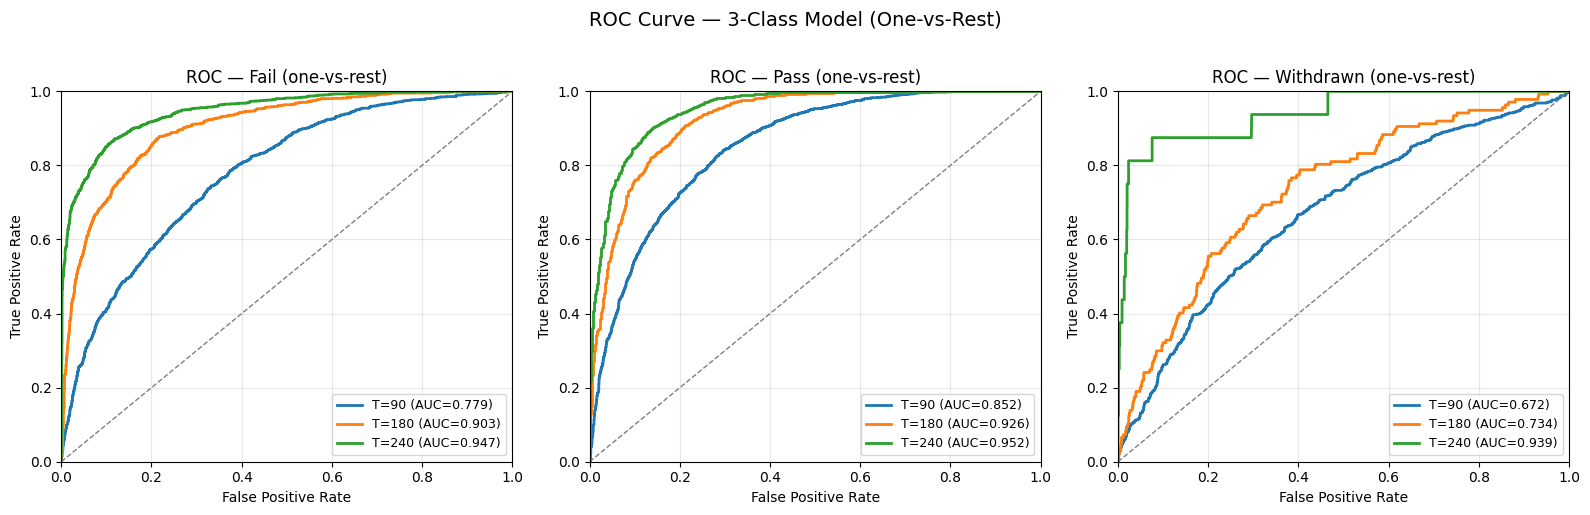

In [34]:
colors = {90: 'tab:blue', 180: 'tab:orange', 240: 'tab:green'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, ci, class_name in zip(axes, range(3), TARGET_NAMES):
    macro_aucs = []
    for T in SNAPSHOTS_3:
        _, X_te_raw, _, y_te = get_snapshot_data(T)
        X_te   = X_te_raw.fillna(0)
        y_proba = models[T].predict_proba(np.array(X_te))

        y_te_bin = label_binarize(y_te, classes=CLASSES)
        fpr, tpr, _ = roc_curve(y_te_bin[:, ci], y_proba[:, ci])
        auc = roc_auc_score(y_te_bin[:, ci], y_proba[:, ci])
        macro_aucs.append(auc)

        ax.plot(fpr, tpr, color=colors[T], linewidth=2,
                label=f'T={T} (AUC={auc:.3f})')

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_title(f'ROC — {class_name} (one-vs-rest)', fontsize=12)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curve — 3-Class Model (One-vs-Rest)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét — ROC 3-Class:**

- **Fail**: AUC thường tăng dần theo snapshot (T=90 → T=240), phản ánh tín hiệu hành vi của nhóm Fail tích lũy rõ hơn qua thời gian — càng về sau càng phân biệt được với Pass.
- **Pass**: AUC cao nhất trong 3 lớp (Pass là lớp đa số, dễ phân biệt nhất), ít biến động theo snapshot.
- **Withdrawn**: AUC thường thấp hơn Fail và Pass, đặc biệt ở T=180 — đây là snapshot mà nhóm Withdrawn còn lại đã co lại nhiều (học sinh withdraw trước 180 ngày đã bị lọc ra), khiến tín hiệu yếu và lẫn lộn với Fail. AUC ở T=90 thường cao hơn T=180 vì mẫu Withdrawn còn đông và signal chưa quá nhiễu.
- Đường ROC của **T=240** cho Withdrawn đôi khi tăng trở lại vì chỉ còn lại các học sinh sắp withdraw trong vòng vài ngày — tín hiệu rất rõ ràng nhưng mẫu cực nhỏ, nên AUC có thể không ổn định.

### Binary — At-risk (Pass vs At-risk)

3 snapshot vẽ trên cùng một biểu đồ để so sánh khả năng phân biệt At-risk/Pass theo thời gian.

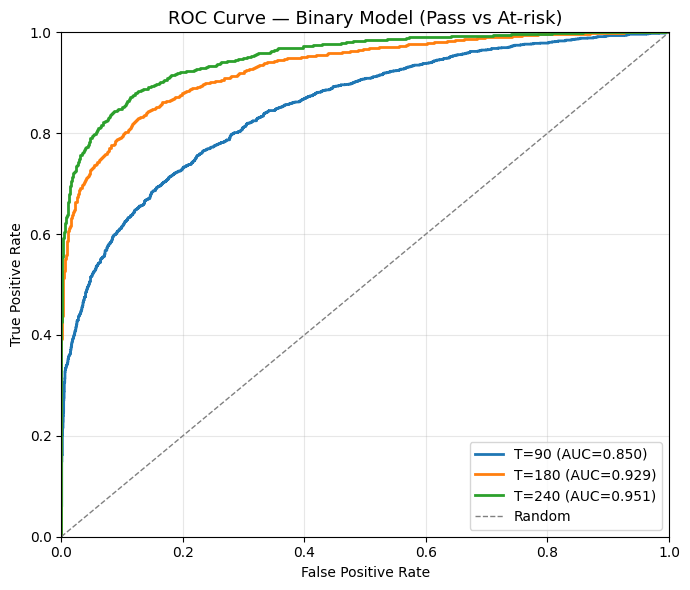

In [35]:
fig, ax = plt.subplots(figsize=(7, 6))

for T in SNAPSHOTS_3:
    _, X_te_raw, _, y_te = get_snapshot_data_bin(T)
    X_te    = X_te_raw.fillna(0)
    y_proba = models_bin[T].predict_proba(np.array(X_te))[:, 1]

    fpr, tpr, _ = roc_curve(y_te, y_proba, pos_label=1)
    auc = roc_auc_score(y_te, y_proba)

    ax.plot(fpr, tpr, color=colors[T], linewidth=2, label=f'T={T} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1, label='Random')
ax.set_title('ROC Curve — Binary Model (Pass vs At-risk)', fontsize=13)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét — ROC Binary:**

- AUC của model binary thường **cao hơn từng lớp riêng lẻ trong 3-class** vì gộp Fail+Withdrawn làm tăng kích thước lớp thiểu số, giúp model học được ranh giới At-risk/Pass rõ ràng hơn.
- Xu hướng **AUC tăng theo T** (T=90 < T=180 < T=240) cho thấy càng về cuối khóa học, hành vi học tập của sinh viên At-risk càng phân kỳ rõ so với Pass — model dự đoán chính xác hơn khi có nhiều dữ liệu hành vi tích lũy.
- Tuy nhiên cần lưu ý: AUC cao ở T=240 một phần do pool At-risk còn lại là những sinh viên có dấu hiệu rất rõ ràng (đã Fail nặng hoặc sắp Withdraw), không hoàn toàn đại diện cho toàn bộ nhóm rủi ro thực tế.
- Đối với mục tiêu **can thiệp sớm**, T=90 với AUC hợp lý là snapshot có giá trị thực tiễn cao nhất — phát hiện sớm khi còn đủ thời gian hỗ trợ sinh viên.